# HW04_Linear_Regression

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [28]:
toyota_data = pd.read_csv("ToyotaCorolla.csv")

toyota_data.info()
toyota_data.describe()
display(toyota_data.columns)

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

Index(['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM',
       'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'CC', 'Doors',
       'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee',
       'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2',
       'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player',
       'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio',
       'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim',
       'Radio_cassette', 'Parking_Assistant', 'Tow_Bar'],
      dtype='str')

In [29]:
print(toyota_data.columns.to_list())

['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant', 'Tow_Bar']


In [30]:
features_to_live = ['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'CC']
display(toyota_data[features_to_live].isnull().sum())
display(toyota_data[features_to_live].dtypes)

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
CC           0
dtype: int64

Price        int64
Age_08_04    int64
KM           int64
Fuel_Type      str
HP           int64
Automatic    int64
CC           int64
dtype: object

### Cleaning dataset
I chose next features to use: 'Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'CC' ('Price' will be the target feature). This chose is based on logical thouts, i think these features will influence on price the most. All features are in int64 datatype, except 'Fuel_type', so we will need to make an one-hot-encoding. There are no null values.

In [31]:
toyota_cleaned = toyota_data[features_to_live].copy()
display(toyota_cleaned.shape)
display(toyota_cleaned.info())

(1436, 7)

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1436 non-null   int64
 1   Age_08_04  1436 non-null   int64
 2   KM         1436 non-null   int64
 3   Fuel_Type  1436 non-null   str  
 4   HP         1436 non-null   int64
 5   Automatic  1436 non-null   int64
 6   CC         1436 non-null   int64
dtypes: int64(6), str(1)
memory usage: 78.7 KB


None

In [32]:
toyota_cleaned['Fuel_Type'].unique()

<StringArray>
['Diesel', 'Petrol', 'CNG']
Length: 3, dtype: str

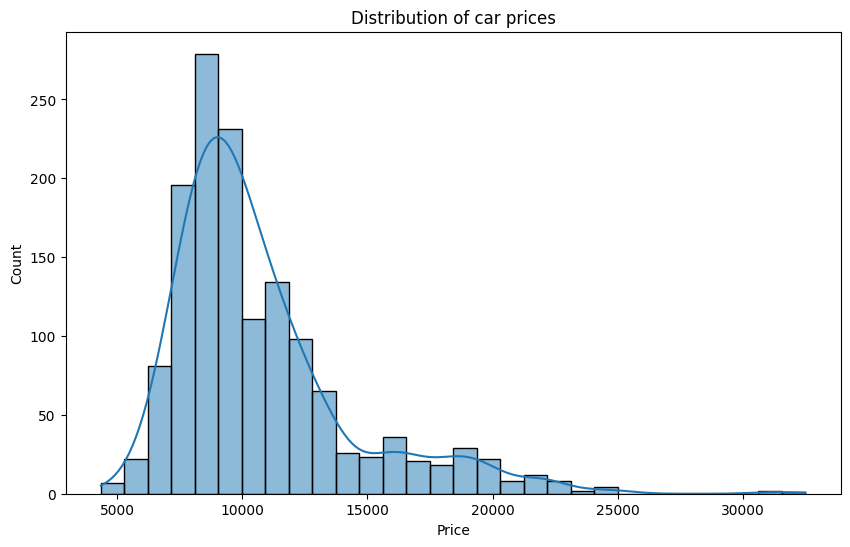

In [33]:
# histogram
plt.figure(figsize=(10,6))
sns.histplot(toyota_cleaned['Price'], bins=30, kde=True)
plt.title("Distribution of car prices")
plt.xlabel("Price")
plt.show()

Most cars have a price 7k-15k$. We also can see there some blowouts with price over 30000. This histogram has right assymetry.

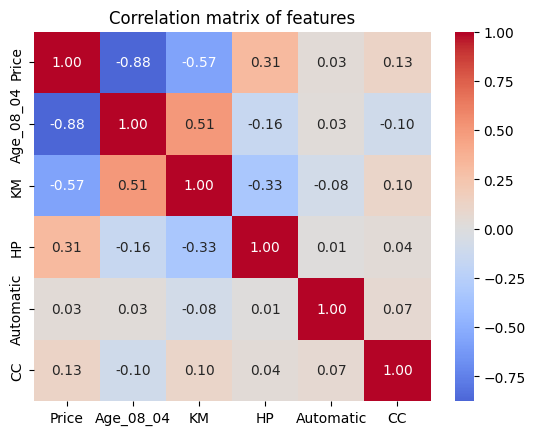

In [34]:
#correlation matrix
numeric_cols = ['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'CC']
corr_matrix = toyota_data[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation matrix of features')
plt.show()

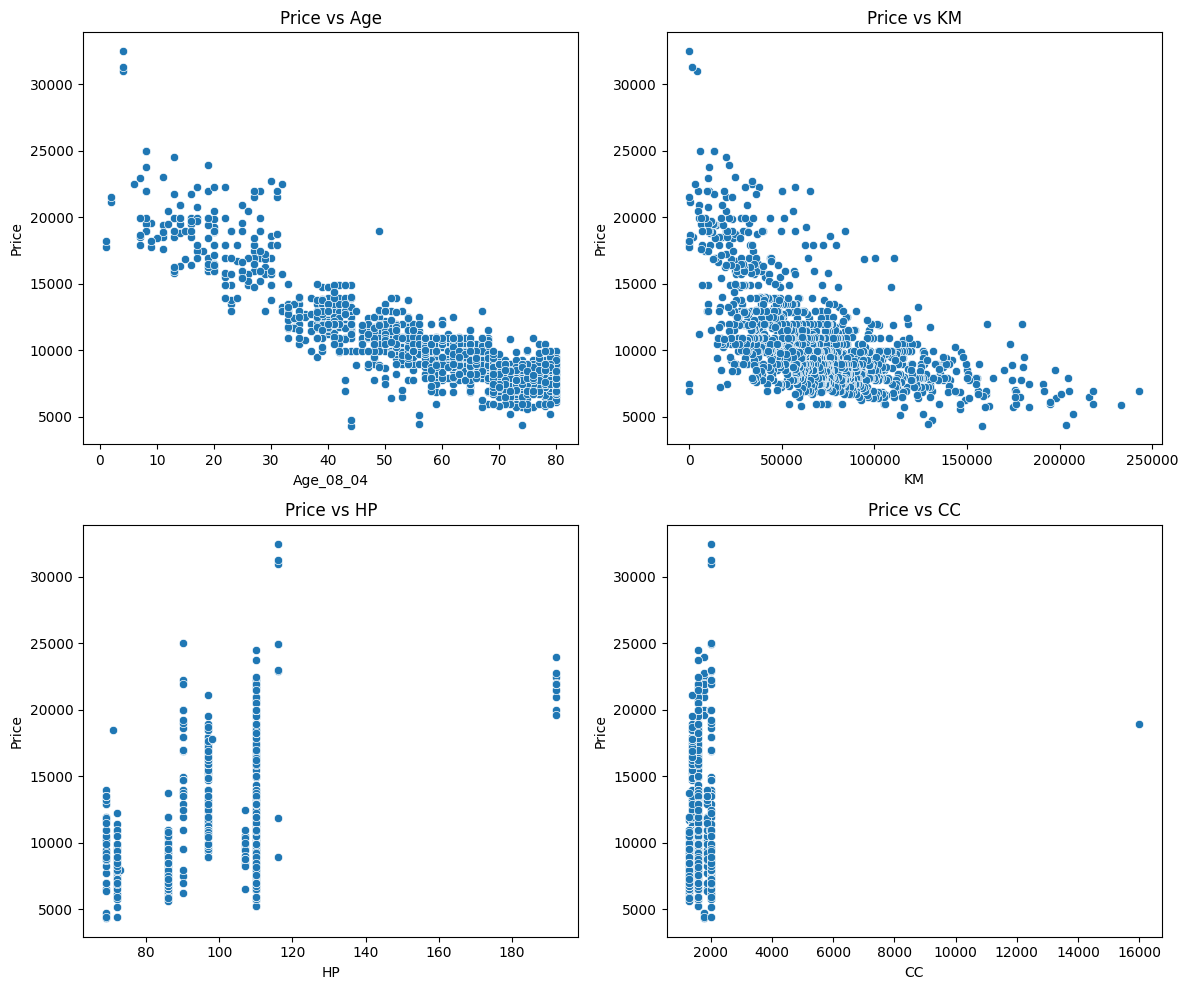

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(data=toyota_cleaned, x='Age_08_04', y='Price', ax=axes[0, 0])
axes[0, 0].set_title('Price vs Age')

sns.scatterplot(data=toyota_cleaned, x='KM', y='Price', ax=axes[0, 1])
axes[0, 1].set_title('Price vs KM')

sns.scatterplot(data=toyota_cleaned, x='HP', y='Price', ax=axes[1, 0])
axes[1, 0].set_title('Price vs HP')

sns.scatterplot(data=toyota_cleaned, x='CC', y='Price', ax=axes[1, 1])
axes[1, 1].set_title('Price vs CC')

plt.tight_layout()
plt.show()

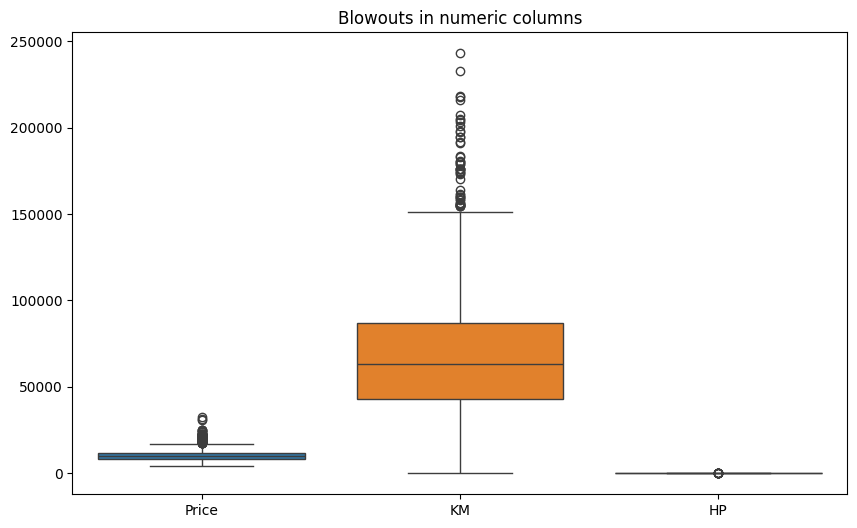

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=toyota_cleaned[['Price', 'KM', 'HP']])
plt.title('Blowouts in numeric columns')
plt.show()

## Analys of plots
From histogram we can see that Automatic and CC have small correlation with Price, so we can work without them, they can only violate our model because it will try to find isues between these features and price. 
Such feature as KM has a lot of outliers, but i will use it because we need to try teach our model to work withh different types of cars (even if their KM bigger than 200k).
The biggest correlation has Age, it will be the main feature for our model (the most influence on price).

In [37]:
df_cleaned = toyota_cleaned[['Price', 'Age_08_04', 'KM', 'HP', 'Fuel_Type']]
display(df_cleaned.shape)
df_cleaned.columns.to_list()

(1436, 5)

['Price', 'Age_08_04', 'KM', 'HP', 'Fuel_Type']

In [38]:
# encoding
df_encoded = pd.get_dummies(df_cleaned, columns=['Fuel_Type'], drop_first=True)
display(df_encoded.shape)
df_encoded.columns.to_list()

(1436, 6)

['Price', 'Age_08_04', 'KM', 'HP', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']

drop_first=True delete column where we could get information about toyotas with CNG, but it is right because we can esialy know it (1 - ('Fuel_Type_Diesel' + 'Fuel_Type_Petrol'))

### Splitting on train and test
To avoid overlearning we need to split data on train and test. If we won't do it model will just remember this data but it won't be able to work in a right way with new one. I'll do splitting 80%(train) TO 20%(test), standard scale

In [39]:
X = df_encoded.drop(['Price'], axis=1) 
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
print(f"Размер Train: {X_train.shape}")
print(f"Размер Test: {X_test.shape}")

Размер Train: (1148, 5)
Размер Test: (288, 5)


### Scaling
Why is it important? If we want do it when we will be doing Ridge and Lasso it'll give us a lot of problems. Such features as Fuel_Type_Diesel (0 or 1) will get too big coefficient and regularization will delete it. On the other hand such features as KM will get small coefficients, that will show that they have not too big influence on price, but that isn't right

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # show data to model
X_test_scaled = scaler.transform(X_test) # DON'T show data to model



### Learning

I used StandardScaler, so now we have all values from 0 to 1

In [41]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

ridge_model = Ridge()
ridge_model.fit(X_train_scaled, y_train)

lasso_model = Lasso()
lasso_model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


the time of learning is very small because of little size of dataset (only ~1400 rows)

In [42]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{model_name}:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  R^2:   {r2:.4f}")
    
    return rmse, mae, r2


results = {}
results['Linear Regression'] = evaluate_model(lr_model, X_test_scaled, y_test, "Linear Regression")
results['Ridge'] = evaluate_model(ridge_model, X_test_scaled, y_test, "Ridge")
results['Lasso'] = evaluate_model(lasso_model, X_test_scaled, y_test, "Lasso")


Linear Regression:
  RMSE: 1474.33
  MAE:  1078.73
  R^2:   0.8371

Ridge:
  RMSE: 1474.51
  MAE:  1078.56
  R^2:   0.8371

Lasso:
  RMSE: 1474.59
  MAE:  1078.52
  R^2:   0.8370


I used metrics RMSE, MAE, R^2. This metrics were calculated on 20% of data (test). Results of each model are almost identical, so we can say that model of Linear regression is good here without regularization (Ridge and Lasso didn't give us any improvment)

### Check overlearning

In [43]:
models = {
    'Linear Regression': lr_model,
    'Ridge': ridge_model,
    'Lasso': lasso_model
}

for name, model in models.items():
    r2_train = model.score(X_train_scaled, y_train)
    r2_test = model.score(X_test_scaled, y_test)
    
    diff = r2_train - r2_test
    
    print(f"\n{name}:")
    print(f"  R² on train: {r2_train:.4f}")
    print(f"  R² on test:  {r2_test:.4f}")
    print(f"  Difference:     {diff:.4f}")
    
    if diff < 0.05:
        print(f"No overlearning")
    elif diff < 0.1:
        print(f"Small overlearning")
    else:
        print(f"Strong overlearning")


Linear Regression:
  R² on train: 0.8292
  R² on test:  0.8371
  Difference:     -0.0079
No overlearning

Ridge:
  R² on train: 0.8292
  R² on test:  0.8371
  Difference:     -0.0079
No overlearning

Lasso:
  R² on train: 0.8292
  R² on test:  0.8370
  Difference:     -0.0079
No overlearning


### Conclusion
1) Main factor for price - age of a car
2) Automatic and CC is features that are unneccessary for model
3) Regularization is unneccessary, Linear Regression is enough for this dataset
4) Scaling of features is crucial in learning on Linear Regression

# HW08_Random_Forest
I will use this notebook and data that i already cleaned here

In [44]:
# additional libraries for Random Forest
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
import time

In [45]:
# just copied cell from the 4th homework, it will be the same as earlier
X = df_encoded.drop(['Price'], axis=1) 
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
print(f"Размер Train: {X_train.shape}")
print(f"Размер Test: {X_test.shape}")

Размер Train: (1148, 5)
Размер Test: (288, 5)


In homework with Linear regression I used scaled data, because it is sensitive to value's range, but it is unnessessary in random forest model, because it looks only on special feature but not on all of them in one moment. The rest of EDA is the same as in the homework with linear regression. I used features ('Price', 'Age_08_04', 'KM', 'HP', 'Fuel_Type'), because I thought that they are the most important for our predictions. 
One-hot-encoding is still nessessary because as lianear regressioin as Random Forest work with numeric datatypes.
Dividing data:
- 80% on trainning
- rest in testing
In cross-validation usualy using 5 folds (4 to 1), they deviding in the same way as i devided data above.
We can avoid using cross-validation to get more speed. It is also more usefull on small datasets

In [46]:
max_depth_val = 5 # max depth of tree

tree_model = DecisionTreeRegressor(
    max_depth=max_depth_val,
    random_state=42,
)

forest_model = RandomForestRegressor(n_estimators=100, max_depth=max_depth_val, random_state=42, n_jobs=-1)

start_time = time.time()
tree_model.fit(X_train, y_train)
tree_train_time = time.time() - start_time

start_time = time.time()
forest_model.fit(X_train, y_train)
forest_train_time = time.time() - start_time

print(f"Время обучения одного дерева (глубина {max_depth_val}): {tree_train_time:.4f} сек")
print(f"Время обучения леса (100 деревьев, глубина {max_depth_val}): {forest_train_time:.4f} сек")
print(f"Лес обучался в {forest_train_time / tree_train_time:.2f} раз дольше.")

y_pred_tree = tree_model.predict(X_test)
y_pred_forest = forest_model.predict(X_test)



Время обучения одного дерева (глубина 5): 0.0018 сек
Время обучения леса (100 деревьев, глубина 5): 0.0854 сек
Лес обучался в 46.16 раз дольше.


Training of forest always will be slower than training of ine tree, because in forest we have 100 of trees, so time that it will take will be ~100 times bigger.

In [47]:
def print_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R^2:  {r2:.4f}")
    return rmse, mae, r2

metrics_tree = print_metrics(y_test, y_pred_tree, "Decision Tree (Single)")
metrics_forest = print_metrics(y_test, y_pred_forest, "Random Forest (Ensemble)")


Decision Tree (Single)
RMSE: 1301.45
MAE:  936.44
R^2:  0.8731

Random Forest (Ensemble)
RMSE: 1122.30
MAE:  853.30
R^2:  0.9056


As we can see, RMSE is better in random forest, because desicion tree tries to care all possibilities and cares outlaws too. But random forest averages the predictions of multiple trees. The errors of individual trees compensate for each other, which makes the final model more robust and accurate based on new data.

Metrics i used:
RMSE, MAE, R^2
These metrics were scored on test part.
The best score on Random forest, because correlation probably is unlinear, so linear model can predict unaccurate. Random forest solve this problem.
RMSE~1122 means that the average prediction error is about 1100$.